In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


train_df = pd.read_csv("mnist_train.csv", header=None)
test_df = pd.read_csv("mnist_test.csv", header=None)

# x - array of pixel intensities, y - array of labels

X_train = train_df.iloc[:, 1:].values
y_train = train_df.iloc[:, 0].values

X_test = test_df.iloc[:, 1:].values
y_test = test_df.iloc[:, 0].values

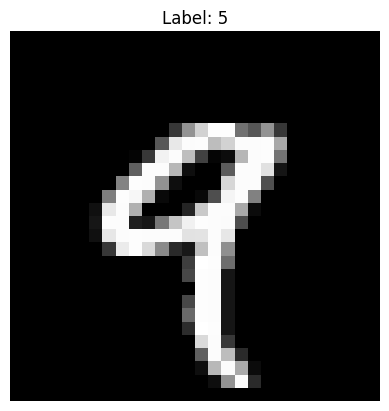

In [57]:
# Visualize images in training set

image = X_train[4].reshape(28, 28)

plt.imshow(image, cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

In [58]:
# Normalize intesities 

X_train = X_train / 255.0
X_test = X_test / 255.0

In [59]:
# Convert labels to parity 

y_train_binary = y_train % 2
y_test_binary = y_test % 2

In [60]:
# Initialize random set of weights and bias

np.random.seed(3)

W = np.random.randn(784) * 0.01
b = 0.0

In [61]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [62]:
# Calculate neuron acivation level given weights, bias and input data

z = np.dot(X_train, W) + b
y_pred = sigmoid(z)

print(y_pred.shape)
print(y_pred[:5])

(60000,)
[0.53006448 0.52361303 0.52040656 0.51391734 0.51028842]


In [63]:
# Calculate binary cross entropy loss across all training samples

eps = 1e-15

loss = -np.mean(
    y_train_binary * np.log(y_pred + eps)
    + (1 - y_train_binary) * np.log(1 - y_pred + eps)
)

print(loss)

0.6959134994533052


In [64]:
# Compute gradients

dz = y_pred - y_train_binary

dW = np.dot(X_train.T, dz) / len(X_train)
db = np.mean(dz)

print(dW.shape)
print(db)
print(dW[:5])

# Gradient descent step

learning_rate = 0.1

W = W - learning_rate * dW
b = b - learning_rate * db

(784,)
0.0009269494478892819
[0. 0. 0. 0. 0.]


In [65]:
# Recompute predictions after update

z = np.dot(X_train, W) + b
y_pred = sigmoid(z)

loss = -np.mean(
    y_train_binary * np.log(y_pred + 1e-15)
    + (1 - y_train_binary) * np.log(1 - y_pred + 1e-15)
)

print(loss)

0.6563884316237355


In [66]:
learning_rate = 0.01
loops = 5000

for loop_number in range(loops):
    z = np.dot(X_train, W) + b
    y_pred = sigmoid(z)

    loss = -np.mean(
        y_train_binary * np.log(y_pred + 1e-15)
        + (1 - y_train_binary) * np.log(1 - y_pred + 1e-15)
    )

    dz = y_pred - y_train_binary
    dW = np.dot(X_train.T, dz) / len(X_train)
    db = np.mean(dz)

    W = W - learning_rate * dW
    b = b - learning_rate * db

    if loop_number % 5 == 0:
        print(f"Loop {loop_number}, Loss: {loss:.4f}")

Loop 0, Loss: 0.6564
Loop 5, Loss: 0.6412
Loop 10, Loss: 0.6273
Loop 15, Loss: 0.6144
Loop 20, Loss: 0.6024
Loop 25, Loss: 0.5914
Loop 30, Loss: 0.5811
Loop 35, Loss: 0.5715
Loop 40, Loss: 0.5626
Loop 45, Loss: 0.5543
Loop 50, Loss: 0.5465
Loop 55, Loss: 0.5393
Loop 60, Loss: 0.5324
Loop 65, Loss: 0.5260
Loop 70, Loss: 0.5199
Loop 75, Loss: 0.5142
Loop 80, Loss: 0.5088
Loop 85, Loss: 0.5037
Loop 90, Loss: 0.4989
Loop 95, Loss: 0.4943
Loop 100, Loss: 0.4899
Loop 105, Loss: 0.4858
Loop 110, Loss: 0.4818
Loop 115, Loss: 0.4780
Loop 120, Loss: 0.4744
Loop 125, Loss: 0.4710
Loop 130, Loss: 0.4677
Loop 135, Loss: 0.4646
Loop 140, Loss: 0.4615
Loop 145, Loss: 0.4586
Loop 150, Loss: 0.4558
Loop 155, Loss: 0.4532
Loop 160, Loss: 0.4506
Loop 165, Loss: 0.4481
Loop 170, Loss: 0.4457
Loop 175, Loss: 0.4434
Loop 180, Loss: 0.4412
Loop 185, Loss: 0.4390
Loop 190, Loss: 0.4370
Loop 195, Loss: 0.4350
Loop 200, Loss: 0.4330
Loop 205, Loss: 0.4311
Loop 210, Loss: 0.4293
Loop 215, Loss: 0.4275
Loop 220, 

In [67]:
# Test predictions

z_test = np.dot(X_test, W) + b
y_test_pred = sigmoid(z_test)

# Convert probabilities to 0 or 1

y_test_class = (y_test_pred >= 0.5).astype(int)

# Accuracy

accuracy = np.mean(y_test_class == y_test_binary)

print("Test accuracy:", accuracy)

Test accuracy: 0.8809
